In [52]:
# Imports and Configurations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.optimize import brentq, minimize, differential_evolution
from scipy.interpolate import interp1d
from scipy.stats import norm
import openpyxl
import warnings, re, sys
warnings.filterwarnings('ignore')

# == Reuse Part 1 bootstrapping codebase ====================================
import nbformat, importlib, types, io, contextlib

def import_notebook_as_module(nb_path, module_name):
    """Import a Jupyter notebook as a Python module."""
    with open(nb_path) as f:
        nb_content = nbformat.read(f, as_version=4)
    module = types.ModuleType(module_name)
    module.__file__ = nb_path
    code_lines = []
    for cell in nb_content.cells:
        if cell.cell_type == 'code':
            src = cell.source
            # Skip lines with jupyter magics or plt.show() calls
            filtered = '\n'.join(
                line for line in src.split('\n')
                if not line.strip().startswith('%')
                and not line.strip().startswith('plt.show')
            )
            code_lines.append(filtered)
    full_code = '\n\n'.join(code_lines)
    # Suppress print output and plot calls during import
    import matplotlib
    _backend = matplotlib.get_backend()
    matplotlib.use('Agg')  # non-interactive backend
    with contextlib.redirect_stdout(io.StringIO()):
        exec(compile(full_code, nb_path, 'exec'), module.__dict__)
    matplotlib.use(_backend)  # restore
    sys.modules[module_name] = module
    return module

part1 = import_notebook_as_module("part1_bootstrapping_swap_curves.ipynb", "part1")

# == Verify Part 1 functions are available ==================================
from part1 import (
    tenor_to_years,          # Convert tenor strings to decimal years
    years_to_label,          # Convert decimal years to tenor labels
    load_market_data,        # Load LIBOR, OIS, Term SOFR data from Excel
    df_interp,               # Linear interpolation on discount factors
    build_payment_schedule,  # Build coupon/payment schedules
    bootstrap_ois,           # Bootstrap OIS (SOFR) discount curve
    bootstrap_term_sofr,     # Bootstrap Term SOFR projection curve
)

# == Retrieve Part 1 bootstrapped curves ====================================
T_ois_arr  = part1.T_ois     # OIS pillar tenors (numpy array)
DF_ois_arr = part1.DF_ois    # OIS discount factors (numpy array)

# Term SOFR forward rates from Part 1 (for reference)
fwd_t_p1   = part1.fwd_t     # Forward rate start dates
fwd_r_p1   = part1.fwd_r     # 3M forward Term SOFR rates

%matplotlib inline
plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "font.size"         : 11,
})

FILEPATH  = "Swap and Swaption Markets.xlsx"
BETA_SABR = 0.75   # Fixed CEV exponent for SABR (II.2)

# Strike column offsets from ATM in the Swaption sheet (11 columns)
STRIKES_BPS = np.array([-200, -150, -100, -50, -25, 0, 25, 50, 100, 150, 200])
BPS_OFFSETS = STRIKES_BPS * 1e-4

# Tenors available in the swaption market grid (used for 30x30 smile construction)
TENORS_AVAIL = [1.0, 2.0, 3.0, 5.0, 10.0]

# Display labels used in parameter tables
EXPIRIES = ["1Y", "5Y", "10Y", "30Y"]
TENORS_U = ["1Y", "2Y", "3Y", "5Y", "10Y", "30Y"]

print("Part 1 bootstrapping codebase imported successfully")
print(f"  Functions: tenor_to_years, df_interp, build_payment_schedule, bootstrap_ois, bootstrap_term_sofr")
print(f"  OIS curve:  {len(T_ois_arr)-1} pillars, T in [0, {T_ois_arr[-1]:.0f}]")
print(f"  Term SOFR:  {len(fwd_t_p1)} quarterly forward rates \n")

print("Part 2 imports and configuration complete")


Part 1 bootstrapping codebase imported successfully
  Functions: tenor_to_years, df_interp, build_payment_schedule, bootstrap_ois, bootstrap_term_sofr
  OIS curve:  32 pillars, T in [0, 50]
  Term SOFR:  120 quarterly forward rates 

Part 2 imports and configuration complete


In [53]:
# == Reuse Part 1 market data for OIS and Term SOFR =========================

_, ois_data_p1, ts_data_p1 = load_market_data(FILEPATH)

# == Load swaption vol surface (Part 2 specific) ============================
wb = openpyxl.load_workbook(FILEPATH, data_only=True)
ws_sw = wb["Swaption"]
swaption_rows = []
for row in ws_sw.iter_rows(min_row=4, values_only=True):
    if row[0] is None or row[1] is None:
        continue
    expiry = str(row[0]).strip()
    tenor  = str(row[1]).strip()
    vols   = [row[i] for i in range(2, 13)]   # 11 cols, in %
    swaption_rows.append((expiry, tenor, vols))
wb.close()

print(f"  Loaded {len(swaption_rows):2d} swaption (expiry x tenor) cells")


  Loaded 11 LIBOR instruments
  Loaded 32 OIS (SOFR) instruments
  Loaded 15 Term-SOFR instruments
  Loaded 15 swaption (expiry x tenor) cells


In [54]:
# Preview swaption vol surface (ATM + wings)
_rows = []
for (exp, ten, vols) in swaption_rows:
    _rows.append({
        "Expiry": exp, "Tenor": ten,
        **{f"{bp:+d}bp": (f"{v:.2f}%" if v is not None else "—")
           for bp, v in zip(STRIKES_BPS, vols)}
    })
df_sw_preview = pd.DataFrame(_rows).set_index(["Expiry", "Tenor"])
display(df_sw_preview.style
    .set_caption("Swaption Market – Lognormal Implied Vols (%)")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"),("font-weight","bold"),("text-align","left"),("padding","6px 0")]},
        {"selector": "th",
         "props": [("background-color","#1F4E79"),("color","white"),
                   ("font-weight","bold"),("text-align","center"),("padding","6px")]},
        {"selector": "tr:nth-child(even) td",
         "props": [("background-color","#D9E1F2")]},
        {"selector": "td", "props": [("text-align","center"),("padding","4px 8px")]},
    ])
)

In [55]:
# == Build callable discount functions from Part 1 bootstrap results =========

def make_discount_callable(T_arr, D_arr):
    """
    Wrap Part 1 bootstrap output into a callable D(t) with flat-forward
    extrapolation beyond the last pillar.
    """
    inner  = interp1d(T_arr, D_arr, kind="linear", fill_value="extrapolate")
    T_max  = T_arr[-1]
    D_max  = float(inner(T_max))
    D_max1 = float(inner(max(T_max - 1.0, 0.0)))
    r_long = -np.log(max(D_max / D_max1, 1e-12))

    def D(t: float) -> float:
        if t <= 0:      return 1.0
        if t <= T_max:  return max(float(inner(t)), 1e-12)
        return max(D_max * np.exp(-r_long * (t - T_max)), 1e-12)
    return D


# == OIS discount curve (from Part 1) ========================================
print("[OIS]       Using Part 1 bootstrap results ...")
D_ois = make_discount_callable(T_ois_arr, DF_ois_arr)

# == Term SOFR projection curve ===============================================
# Re-bootstrap using Part 1 bootstrap_term_sofr() with OIS discounting
print("[Term SOFR] Bootstrapping via Part 1 bootstrap_term_sofr() ...")
_, _, fwd_t_ts, fwd_r_ts = bootstrap_term_sofr(ts_data_p1, T_ois_arr, DF_ois_arr)

# Build Term SOFR discount factors from the quarterly forward rates
# D_TS(0, t_{i+1}) = D_TS(0, t_i) / (1 + f_i * 0.25)
alpha_q = 0.25
q_grid  = np.concatenate([[0.0], fwd_t_ts + alpha_q])
d_ts_vals = [1.0]
for fr in fwd_r_ts:
    d_ts_vals.append(d_ts_vals[-1] / (1.0 + fr * alpha_q))
T_ts_arr  = np.array(q_grid)
D_ts_arr  = np.array(d_ts_vals)
D_ts = make_discount_callable(T_ts_arr, D_ts_arr)

print("\n  Check points (Part 1 curves reused):")
hdr = f"  {'T':>4}  {'D_OIS':>10}  {'D_TS':>10}"
print(hdr); print('  ' + '-' * 28)
for t in [1, 5, 10, 20, 30, 50]:
    print(f"  {t:>4}  {D_ois(t):>10.6f}  {D_ts(t):>10.6f}")


[OIS]       Using Part 1 bootstrap results ...
[Term SOFR] Bootstrapping via Part 1 bootstrap_term_sofr() ...

  Check points (Part 1 curves reused):
     T       D_OIS        D_TS
  ----------------------------
     1    0.966224    0.955360
     5    0.839451    0.824353
    10    0.680901    0.680525
    20    0.427583    0.444666
    30    0.282910    0.293202
    50    0.151716    0.118980


In [56]:
# == Build Multi-Curve Forward Swap Rates & Annuities =========

def annuity(T_exp: float, T_ten: float, D_ois, freq: float = 1.0) -> float:
    """OIS-discounted fixed-leg annuity factor."""
    pts = np.arange(T_exp + freq, T_exp + T_ten + 1e-9, freq)
    return float(sum(D_ois(t) * freq for t in pts))

def fwd_swap_rate(T_exp: float, T_ten: float, D_ois, D_ts) -> float:
    """Multi-curve par forward swap rate: (D_TS(Te) - D_TS(Te+Tn)) / A_OIS."""
    A = annuity(T_exp, T_ten, D_ois)
    return (D_ts(T_exp) - D_ts(T_exp + T_ten)) / A

# Display forward swap rate grid
pairs = [(1,1),(1,2),(1,3),(1,5),(1,10),
         (5,1),(5,2),(5,3),(5,5),(5,10),
         (10,1),(10,2),(10,3),(10,5),(10,10),
         (30,30)]
rows = []
for (Te, Tn) in pairs:
    F = fwd_swap_rate(Te, Tn, D_ois, D_ts)
    A = annuity(Te, Tn, D_ois)
    rows.append({"Expiry (y)": Te, "Tenor (y)": Tn,
                 "Label": f"{Te}Y×{Tn}Y",
                 "Forward Rate F (%)": round(F * 100, 4),
                 "Annuity A": round(A, 4)})

df_fwd = pd.DataFrame(rows).set_index("Label")
display(df_fwd.style
    .format({"Forward Rate F (%)": "{:.4f}%", "Annuity A": "{:.4f}"})
    .set_caption("Multi-Curve Forward Swap Rates and Annuity Factors")
)

,Expiry (y),Tenor (y),Forward Rate F (%),Annuity A
Label,,,,
1Y×1Y,1,1,3.9767%,0.9353
1Y×2Y,1,2,3.8189%,1.8391
1Y×3Y,1,3,3.7257%,2.7108
1Y×5Y,1,5,3.6902%,4.3573
1Y×10Y,1,10,3.8120%,7.9186
5Y×1Y,5,1,3.6905%,0.8070
5Y×2Y,5,2,3.7018%,1.5818
5Y×3Y,5,3,3.7536%,2.3247
5Y×5Y,5,5,3.8693%,3.7172


---
## Synthetic 30×30 Smile

The 30×30 swaption lies outside the calibrated grid (max available tenor = 10Y).
A synthetic smile is constructed in two steps:

**Step 1 – Extrapolate the ATM vol** linearly across tenors at the 10Y expiry row, obtaining a new ATM level for tenor = 30Y.

**Step 2 – Borrow the smile *shape*** (skew = vol − ATM) from the 10Y×10Y slice, then shift it to the extrapolated ATM level:

$$\sigma_{\text{synth}}(K) = \sigma_{\text{ATM,extrap}} + \underbrace{\left[\sigma_{\text{10×10}}(K) - \sigma_{\text{ATM,10×10}}\right]}_{\text{skew from 10×10}}$$

This preserves realistic wing behaviour — simple linear extrapolation per strike would allow left-wing vols to go negative.

In [57]:
def build_synthetic_smile(raw_vols: dict, T_ten_target: float,
                           base_T_exp: float = 10.0) -> list:
    """Extrapolated ATM vol + borrowed smile shape from longest available tenor."""
    atm_by_tenor = [raw_vols[(base_T_exp, Tn)][5] for Tn in TENORS_AVAIL]
    fn_atm       = interp1d(TENORS_AVAIL, atm_by_tenor,
                            kind="linear", fill_value="extrapolate")
    atm_target   = max(float(fn_atm(T_ten_target)), 0.01)

    vols_base = raw_vols[(base_T_exp, max(TENORS_AVAIL))]
    atm_base  = vols_base[5]
    skew      = [v - atm_base for v in vols_base]
    return [max(atm_target + sk, 0.01) for sk in skew]


def build_swaption_slices(swaption_rows, raw_vols_decimal, D_ois, D_ts):
    """Assemble slice dicts (one per expiry×tenor cell) including synthetic 30×30."""
    slices = []
    for (exp_str, ten_str, vols_pct) in swaption_rows:
        T_exp = tenor_to_years(exp_str)
        T_ten = tenor_to_years(ten_str)
        F     = fwd_swap_rate(T_exp, T_ten, D_ois, D_ts)
        A     = annuity(T_exp, T_ten, D_ois)
        slices.append({
            "label": f"{exp_str}x{ten_str}", "exp_str": exp_str, "ten_str": ten_str,
            "T_exp": T_exp, "T_ten": T_ten, "F": F, "A": A,
            "strikes": F + BPS_OFFSETS, "vols_pct": vols_pct,
        })

    F_30 = fwd_swap_rate(30.0, 30.0, D_ois, D_ts)
    A_30 = annuity(30.0, 30.0, D_ois)
    vols_30_pct = [v * 100.0 for v in build_synthetic_smile(raw_vols_decimal, 30.0)]
    slices.append({
        "label": "30Yx30Y", "exp_str": "30Y", "ten_str": "30Y",
        "T_exp": 30.0, "T_ten": 30.0, "F": F_30, "A": A_30,
        "strikes": F_30 + BPS_OFFSETS, "vols_pct": vols_30_pct, "synthetic": True,
    })
    return slices

# Build raw vols dict (decimal) for smile construction
raw_vols_dec = {}
for (exp_str, ten_str, vols_pct) in swaption_rows:
    Te = tenor_to_years(exp_str); Tn = tenor_to_years(ten_str)
    raw_vols_dec[(Te, Tn)] = [(v / 100.0 if v is not None else np.nan) for v in vols_pct]

swaption_slices = build_swaption_slices(swaption_rows, raw_vols_dec, D_ois, D_ts)

# Show the synthetic 30×30 smile
sl30 = swaption_slices[-1]
print(f"Synthetic 30×30:  F = {sl30['F']*100:.4f}%   A = {sl30['A']:.4f}")
df_30 = pd.DataFrame({
    "Strike Offset (bp)": STRIKES_BPS,
    "Strike K (%)":       [round(k*100, 4) for k in sl30["strikes"]],
    "Synthetic Vol (%)":  [round(v, 4) for v in sl30["vols_pct"]],
})
display(df_30.style
    .format({"Strike K (%)": "{:.4f}%", "Synthetic Vol (%)": "{:.4f}%"})
    .set_caption("Synthetic 30×30 Smile")
)

Synthetic 30×30:  F = 4.0285%   A = 5.3968


,Strike Offset (bp),Strike K (%),Synthetic Vol (%)
0,-200,2.0285%,24.1210%
1,-150,2.5285%,21.0290%
2,-100,3.0285%,18.4980%
3,-50,3.5285%,16.4460%
4,-25,3.7785%,15.6060%
5,0,4.0285%,14.8900%
6,25,4.2785%,14.2800%
7,50,4.5285%,13.7600%
8,100,5.0285%,12.9600%
9,150,5.5285%,12.4200%


---
## Option Pricing Functions

### Black-76

$$V_{\text{payer}} = A\bigl[F\,N(d_1) - K\,N(d_2)\bigr], \quad
d_{1,2} = \frac{\ln(F/K) \pm \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}$$

### Displaced-Diffusion (Neo & Tee 2018, §3.2)

SDE: $dF_t = \sigma\bigl[\beta F_t + (1-\beta)F_0\bigr]\,dW_t$

The displaced forward $G_t = F_t + \frac{1-\beta}{\beta}F_0$ follows a GBM, giving a closed form via Black-76 on displaced variables:

$$F' = \frac{F_0}{\beta}, \quad K' = K + \frac{1-\beta}{\beta}F_0, \quad \sigma' = \beta\sigma$$

### SABR (Hagan et al. 2002)

SDE: $dF_t = \alpha_t\,F_t^\beta\,dW_t,\ d\alpha_t = \nu\,\alpha_t\,dZ_t,\ \langle dW, dZ\rangle = \rho\,dt$

ATM approximation ($F = K$):

$$\sigma_B^{\text{ATM}} = \frac{\alpha}{F^{1-\beta}}\left[1 + \left(\frac{(1-\beta)^2\alpha^2}{24F^{2(1-\beta)}} + \frac{\rho\beta\nu\alpha}{4F^{1-\beta}} + \frac{(2-3\rho^2)\nu^2}{24}\right)T\right]$$

In [58]:
def black_price(F, K, T, sigma, A=1.0, is_payer=True):
    """Black-76 swaption price."""
    if sigma < 1e-8 or K <= 0:
        return (max(F-K,0.) if is_payer else max(K-F,0.)) * A
    d1 = (np.log(F/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if is_payer: return A * (F*norm.cdf(d1)  - K*norm.cdf(d2))
    else:        return A * (K*norm.cdf(-d2) - F*norm.cdf(-d1))


def black_iv(price, F, K, T, A=1.0, is_payer=True):
    """Invert Black-76 for lognormal implied vol via Brent's method."""
    intrinsic = (max(F-K,0.) if is_payer else max(K-F,0.)) * A
    if price <= intrinsic + 1e-12: return np.nan
    f = lambda s: black_price(F, K, T, s, A, is_payer) - price
    if f(20.0) < 0: return np.nan
    if f(1e-6) > 0: return 1e-6
    try:    return brentq(f, 1e-6, 20.0, xtol=1e-10)
    except: return np.nan


def dd_price(F, K, T, sigma, beta, A=1.0, is_payer=True):
    """Displaced-Diffusion swaption price (Neo & Tee 2018 §3.2)."""
    if beta <= 0:
        return (max(F-K,0.) if is_payer else max(K-F,0.)) * A
    F_p   = F / beta
    K_p   = K + (1.0-beta)/beta * F
    sig_e = beta * sigma
    if F_p <= 0 or K_p <= 0:
        return (max(F-K,0.) if is_payer else max(K-F,0.)) * A
    return black_price(F_p, K_p, T, sig_e, A, is_payer)


def dd_implied_lognormal_vol(F, K, T, sigma, beta, A, is_payer=True):
    """Convert DD price to Black-76 lognormal implied vol."""
    if K <= 0 or beta <= 0: return np.nan
    return black_iv(dd_price(F, K, T, sigma, beta, A, is_payer), F, K, T, A, is_payer)


def sabr_vol(F, K, T, alpha, beta, rho, nu):
    """Hagan et al. (2002) SABR lognormal implied vol."""
    eps = 1e-7
    if F <= 0 or K <= 0 or T <= 0: return 0.001
    if abs(F - K) < eps:
        FK_1mb      = F**(2.*(1.-beta))
        FK_half_1mb = F**(1.-beta)
        ex = ((1.-beta)**2*alpha**2/(24.*FK_1mb)
              + rho*beta*nu*alpha/(4.*FK_half_1mb)
              + (2.-3.*rho**2)*nu**2/24.)
        return max(alpha / F**(1.-beta) * (1. + ex*T), 1e-4)

    log_fk      = np.log(F/K)
    FK_half_1mb = (F*K)**((1.-beta)/2.)
    FK_1mb      = (F*K)**(1.-beta)
    D    = 1. + (1.-beta)**2/24.*log_fk**2 + (1.-beta)**4/1920.*log_fk**4
    z    = (nu/alpha) * FK_half_1mb * log_fk
    carg = (np.sqrt(max(1.-2.*rho*z+z**2,0.)) + z - rho) / (1.-rho)
    if carg <= 0: return 0.001
    chi  = np.log(carg)
    zchi = z/chi if abs(chi) > eps else 1.
    ex   = ((1.-beta)**2*alpha**2/(24.*FK_1mb)
            + rho*beta*nu*alpha/(4.*FK_half_1mb)
            + (2.-3.*rho**2)*nu**2/24.)
    return max(alpha/(FK_half_1mb*D) * zchi * (1.+ex*T), 1e-4)

---
## Part II.1 – Displaced-Diffusion Calibration

**Model**: $dF_t = \sigma\bigl[\beta F_t + (1-\beta)F_0\bigr]\,dW_t$

Two parameters per slice:
- $\sigma$ — DD volatility level
- $\beta \in (0,1]$ — displacement backbone ($\beta=1$ recovers Black-76)

**Calibration objective** (price-space, OTM convention):
$$\min_{\sigma,\,\beta}\;\sum_i \left[\frac{V_{\text{DD}}(K_i;\sigma,\beta) - V_{\text{mkt}}(K_i)}{A}\right]^2$$

Two-stage optimiser: `differential_evolution` (global) → `L-BFGS-B` (bounded polish).  
This notebook calibrates all 16 slices sequentially — **this cell takes a few minutes to run**.

In [59]:
def calibrate_dd_single(mkt_vols_pct, strikes, F, T, A):
    """Calibrate (σ, β) for one (expiry, tenor) swaption cell."""
    mkt_prices = []
    for K, v_pct in zip(strikes, mkt_vols_pct):
        if v_pct is None or (isinstance(v_pct, float) and np.isnan(v_pct)) or K <= 0:
            continue
        is_p = (K >= F)
        mkt_prices.append((K, black_price(F, K, T, v_pct/100., A, is_p), is_p))
    if not mkt_prices:
        return 0.20, 0.5, np.nan

    def objective(params):
        sig, b = params
        if sig < 1e-4 or b <= 0: return 1e9
        return sum(((dd_price(F, K, T, sig, b, A, ip) - pm)/A)**2
                   for K, pm, ip in mkt_prices)

    BOUNDS_DD = [(0.001, 5.0), (1e-4, 1.0)]
    rg = differential_evolution(objective, bounds=BOUNDS_DD,
                                seed=42, maxiter=2000, popsize=15, tol=1e-10,
                                mutation=(0.5,1.5), recombination=0.9)
    rl = minimize(objective, rg.x, method="L-BFGS-B", bounds=BOUNDS_DD,
                  options={"maxiter":10_000,"ftol":1e-14,"gtol":1e-10})
    sig, b = np.clip(rl.x, [bd[0] for bd in BOUNDS_DD], [bd[1] for bd in BOUNDS_DD])
    rmse = np.sqrt(rl.fun/len(mkt_prices)) if mkt_prices else np.nan
    return float(sig), float(b), float(rmse)


def calibrate_dd_grid(swaption_slices):
    """Calibrate DD across the full grid. Returns sigma_table, beta_table."""
    sigma_table, beta_table = {}, {}
    print(f"  {'Slice':>12} {'F (%)':>7} {'σ':>8} {'β':>8}  RMSE")
    print("  " + "-" * 48)
    for sl in swaption_slices:
        sig, b, rmse = calibrate_dd_single(
            sl["vols_pct"], sl["strikes"], sl["F"], sl["T_exp"], sl["A"])
        key = (sl["exp_str"], sl["ten_str"])
        sigma_table[key] = sig; beta_table[key] = b
        sl["dd_params"] = (sig, b)
        rmse_str = f"{rmse:.6f}" if np.isfinite(rmse) else "  n/a  "
        print(f"  {sl['label']:>12}  {sl['F']*100:>6.3f}  {sig:>8.4f}  {b:>8.4f}  {rmse_str}")
    return sigma_table, beta_table

print("⏳ Calibrating Displaced-Diffusion model (all 16 slices) …")
sigma_table, beta_table = calibrate_dd_grid(swaption_slices)
print("\n✓ DD calibration complete")

⏳ Calibrating Displaced-Diffusion model (all 16 slices) …
         Slice   F (%)        σ        β  RMSE
  ------------------------------------------------
         1Yx1Y   3.977    0.2740    0.0001  0.001231
         1Yx2Y   3.819    0.3259    0.0001  0.000834
         1Yx3Y   3.726    0.3253    0.0001  0.000563
         1Yx5Y   3.690    0.2739    0.0001  0.000258
        1Yx10Y   3.812    0.2514    0.2889  0.000127
         5Yx1Y   3.691    0.2993    0.0001  0.001355
         5Yx2Y   3.702    0.3108    0.0001  0.000730
         5Yx3Y   3.754    0.3072    0.0001  0.000537
         5Yx5Y   3.869    0.2695    0.0001  0.000266
        5Yx10Y   4.084    0.2468    0.2114  0.000170
        10Yx1Y   4.149    0.2952    0.0001  0.001265
        10Yx2Y   4.246    0.2964    0.0001  0.000945
        10Yx3Y   4.240    0.2938    0.0001  0.000680
        10Yx5Y   4.351    0.2656    0.0001  0.000415
       10Yx10Y   4.420    0.2416    0.1194  0.000207
       30Yx30Y   4.029    0.1482    0.0001  0.000

### II.1 Results – DD Parameter Tables

**Interpretation:**
- **σ** controls the overall volatility level. The effective lognormal vol seen by the market is $\sigma' = \beta\sigma$.
- **β** controls the backbone and skew shape:
  - $\beta = 1$: pure Black-76 (no displacement)
  - $\beta \to 0$: near-normal dynamics, large downward skew, negative rates admissible down to $-\frac{1-\beta}{\beta}F_0$
- DD has only **two free parameters** — it cannot independently control skew slope and smile curvature (unlike SABR).

In [60]:
def make_param_df(table, exp_keys=EXPIRIES, ten_keys=TENORS_U):
    """Pivot a {(exp, ten): val} dict into a DataFrame (expiry × tenor)."""
    rows = []
    for e in exp_keys:
        if not any(k[0]==e for k in table): continue
        row = {"Expiry": e}
        for t in ten_keys:
            row[t] = table.get((e,t), np.nan)
        rows.append(row)
    return pd.DataFrame(rows).set_index("Expiry")

def style_param_table(df, caption, hdr_color="#1F4E79", fmt="{:.4f}", cmap="Blues"):
    cols = [c for c in df.columns if not df[c].isna().all()]
    return (df[cols].style
        .format(fmt, na_rep="—")
        .set_caption(caption)
    )

df_sigma = make_param_df(sigma_table)
df_beta  = make_param_df(beta_table)

print("── σ  (DD volatility parameter) ──")
display(style_param_table(df_sigma,
    "II.1 – Displaced-Diffusion: σ Parameter  [SDE: dFt = σ·(β·Ft + (1−β)·F₀)·dWt]"))

print("\n── β  (displacement / backbone parameter) ──")
display(style_param_table(df_beta,
    "II.1 – Displaced-Diffusion: β Parameter  [β=1 → Black-76;  β→0 → near-normal]"))

── σ  (DD volatility parameter) ──


,1Y,2Y,3Y,5Y,10Y,30Y
Expiry,,,,,,
1Y,0.2740,0.3259,0.3253,0.2739,0.2514,—
5Y,0.2993,0.3108,0.3072,0.2695,0.2468,—
10Y,0.2952,0.2964,0.2938,0.2656,0.2416,—
30Y,—,—,—,—,—,0.1482



── β  (displacement / backbone parameter) ──


,1Y,2Y,3Y,5Y,10Y,30Y
Expiry,,,,,,
1Y,0.0001,0.0001,0.0001,0.0001,0.2889,—
5Y,0.0001,0.0001,0.0001,0.0001,0.2114,—
10Y,0.0001,0.0001,0.0001,0.0001,0.1194,—
30Y,—,—,—,—,—,0.0001


---
## Part II.2 – SABR Calibration  ($\beta_{\text{CEV}} = 0.75$ fixed)

**Model** (Hagan et al. 2002):
$$dF_t = \alpha_t\,F_t^\beta\,dW_t, \quad d\alpha_t = \nu\,\alpha_t\,dZ_t, \quad \langle dW, dZ\rangle = \rho\,dt$$

Three free parameters with $\beta = 0.75$ fixed:
- $\alpha$ — vol backbone (ATM vol $\approx \alpha/F^{1-\beta}$)
- $\rho$ — vol-rate correlation (typically $< 0$ for rates: downward skew)
- $\nu$ — vol-of-vol (controls smile curvature; $\nu = 0$ gives flat smile)

**Calibration objective** (vol-space):
$$\min_{\alpha,\,\rho,\,\nu}\;\sum_i \bigl[\sigma_{\text{SABR}}(K_i) - \sigma_{\text{mkt}}(K_i)\bigr]^2$$

**This cell also takes a few minutes to run.**

In [61]:
def calibrate_sabr_single(mkt_vols_pct, strikes, F, T, beta=BETA_SABR):
    """Calibrate (α, ρ, ν) for one cell with β fixed."""
    valid = [(K, v/100.) for K, v in zip(strikes, mkt_vols_pct)
             if v is not None and not (isinstance(v,float) and np.isnan(v)) and K > 0]
    if not valid: return 0.01, 0., 0.3, np.nan
    ks  = np.array([x[0] for x in valid])
    mvs = np.array([x[1] for x in valid])
    atm_vol = mvs[int(np.argmin(np.abs(ks - F)))]
    alpha0  = atm_vol * F**(1.-beta)

    def objective(params):
        a, rho, nu = params
        if a <= 0 or nu <= 0 or abs(rho) >= 0.999: return 1e9
        return sum((sabr_vol(F, K, T, a, beta, rho, nu) - mv)**2
                   for K, mv in zip(ks, mvs))

    BOUNDS_SABR = [(1e-4,1.0),(-0.998,0.998),(1e-4,5.0)]
    rg = differential_evolution(objective, bounds=BOUNDS_SABR,
                                seed=42, maxiter=3000, popsize=20, tol=1e-12,
                                mutation=(0.5,1.5), recombination=0.9)
    rl = minimize(objective, x0=rg.x, method="L-BFGS-B", bounds=BOUNDS_SABR,
                  options={"maxiter":20_000,"ftol":1e-15,"gtol":1e-10})
    a, rho, nu = np.clip(rl.x, [b[0] for b in BOUNDS_SABR], [b[1] for b in BOUNDS_SABR])
    rmse_bps = np.sqrt(rl.fun/len(valid))*1e4
    return float(a), float(rho), float(nu), float(rmse_bps)


def calibrate_sabr_grid(swaption_slices, beta=BETA_SABR):
    """Calibrate SABR across the full grid. Returns alpha, rho, nu tables."""
    alpha_table, rho_table, nu_table = {}, {}, {}
    print(f"  {'Slice':>12} {'F (%)':>7} {'α':>8} {'ρ':>8} {'ν':>8}  RMSE(bp)")
    print("  " + "-" * 58)
    for sl in swaption_slices:
        a, rho, nu, rmse = calibrate_sabr_single(
            sl["vols_pct"], sl["strikes"], sl["F"], sl["T_exp"], beta)
        key = (sl["exp_str"], sl["ten_str"])
        alpha_table[key] = a; rho_table[key] = rho; nu_table[key] = nu
        sl["sabr_params"] = (a, beta, rho, nu)
        atm_chk = sabr_vol(sl["F"], sl["F"], sl["T_exp"], a, beta, rho, nu)*100
        mkt_str = f"{sl['vols_pct'][5]:.2f}%" if sl["vols_pct"][5] is not None else "synth"
        print(f"  {sl['label']:>12}  {sl['F']*100:>6.3f}  {a:>8.4f}  {rho:>8.4f}"
              f"  {nu:>8.4f}  {rmse:>6.2f}   [ATM: mdl={atm_chk:.2f}% mkt={mkt_str}]")
    return alpha_table, rho_table, nu_table

print("⏳ Calibrating SABR model (all 16 slices) …")
alpha_table, rho_table, nu_table = calibrate_sabr_grid(swaption_slices)
print("\n✓ SABR calibration complete")

⏳ Calibrating SABR model (all 16 slices) …
         Slice   F (%)        α        ρ        ν  RMSE(bp)
  ----------------------------------------------------------
         1Yx1Y   3.977    0.0843   -0.6758    2.6117  403.11   [ATM: mdl=21.09% mkt=22.50%]
         1Yx2Y   3.819    0.1104   -0.5318    1.9025  226.81   [ATM: mdl=28.13% mkt=28.72%]
         1Yx3Y   3.726    0.1180   -0.4698    1.5459  130.78   [ATM: mdl=29.47% mkt=29.78%]
         1Yx5Y   3.690    0.1076   -0.3817    1.0891   38.53   [ATM: mdl=25.99% mkt=26.07%]
        1Yx10Y   3.812    0.1042   -0.2015    0.7544    3.97   [ATM: mdl=24.47% mkt=24.47%]
         5Yx1Y   3.691    0.0983   -0.5441    1.1822  235.30   [ATM: mdl=26.67% mkt=27.26%]
         5Yx2Y   3.702    0.1183   -0.4991    0.9062   86.66   [ATM: mdl=29.69% mkt=29.83%]
         5Yx3Y   3.754    0.1243   -0.5029    0.8009   50.62   [ATM: mdl=29.93% mkt=29.98%]
         5Yx5Y   3.869    0.1142   -0.4550    0.5773   14.91   [ATM: mdl=26.61% mkt=26.60%]
        

### II.2 Results – SABR Parameter Tables

**Interpretation:**
- **α**: overall vol backbone — ATM vol $\approx \alpha / F^{1-\beta}$. Tends to be larger for short expiries.
- **ρ**: typically negative in interest rate markets (rise in rates → fall in vol), producing a downward-sloping skew (ITM payer vols < OTM payer vols).
- **ν**: vol-of-vol — higher ν implies more curvature (smile "bowl") around ATM.

In [62]:
df_alpha = make_param_df(alpha_table)
df_rho   = make_param_df(rho_table)
df_nu    = make_param_df(nu_table)

print("── α  (SABR vol backbone) ──")
display(style_param_table(df_alpha,
    f"II.2 – SABR: α Parameter  (β_CEV = {BETA_SABR} fixed)  "
    f"[ATM vol ≈ α / F^{{1−β}}]",
    hdr_color="#375623", cmap="Greens"))

print("\n── ρ  (vol-rate correlation / skew) ──")
display(style_param_table(df_rho,
    f"II.2 – SABR: ρ Parameter  (β_CEV = {BETA_SABR} fixed)  "
    f"[ρ < 0 → downward skew typical in rates]",
    hdr_color="#375623", cmap="RdYlGn"))

print("\n── ν  (vol-of-vol / smile curvature) ──")
display(style_param_table(df_nu,
    f"II.2 – SABR: ν Parameter  (β_CEV = {BETA_SABR} fixed)  "
    f"[ν > 0 → symmetric curvature around ATM]",
    hdr_color="#375623", cmap="Oranges"))

── α  (SABR vol backbone) ──


,1Y,2Y,3Y,5Y,10Y,30Y
Expiry,,,,,,
1Y,0.0843,0.1104,0.1180,0.1076,0.1042,—
5Y,0.0983,0.1183,0.1243,0.1142,0.1071,—
10Y,0.1052,0.1153,0.1220,0.1186,0.1086,—
30Y,—,—,—,—,—,0.0684



── ρ  (vol-rate correlation / skew) ──


,1Y,2Y,3Y,5Y,10Y,30Y
Expiry,,,,,,
1Y,-0.6758,-0.5318,-0.4698,-0.3817,-0.2015,—
5Y,-0.5441,-0.4991,-0.5029,-0.4550,-0.3556,—
10Y,-0.5146,-0.5116,-0.5137,-0.5181,-0.4318,—
30Y,—,—,—,—,—,-0.5891



── ν  (vol-of-vol / smile curvature) ──


,1Y,2Y,3Y,5Y,10Y,30Y
Expiry,,,,,,
1Y,2.6117,1.9025,1.5459,1.0891,0.7544,—
5Y,1.1822,0.9062,0.8009,0.5773,0.4304,—
10Y,0.9194,0.8349,0.7546,0.6033,0.4288,—
30Y,—,—,—,—,—,0.3658


---
## Part II.3 – Vol Profiles & Smile Fit Plots

Three target swaptions are examined across $K \in [1\%, 10\%]$:
- **Payer 1×1** — short-dated, high vol, strong skew from near-zero rates
- **Payer 10×10** — mid-curve benchmark
- **Receiver 30×30** — long-dated, synthetic smile, flat profile expected

Both DD (blue solid) and SABR (orange dashed) implied lognormal vol profiles are overlaid. Market / synthetic quotes are shown as scatter points.

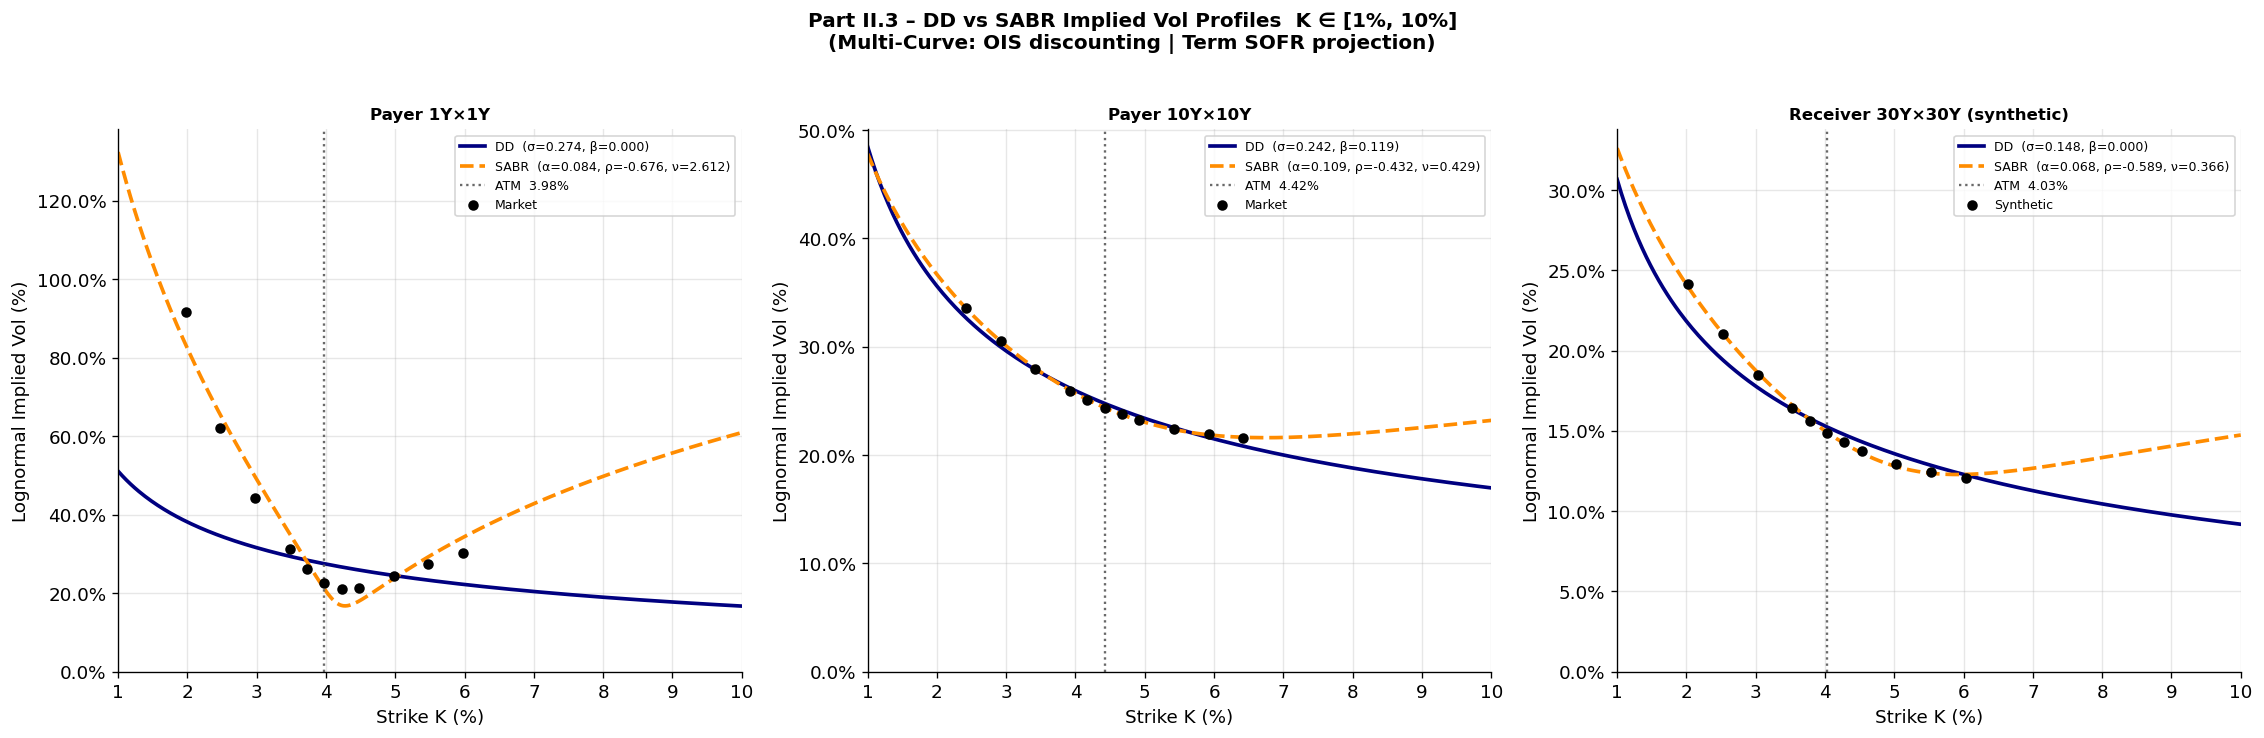

In [68]:
K_range = np.linspace(0.01, 0.10, 300)
targets = [("1Y", "1Y", True), ("10Y", "10Y", True), ("30Y", "30Y", False)]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

for ax, (exp_str, ten_str, is_payer) in zip(axes, targets):
    sl = next((s for s in swaption_slices
               if s["exp_str"] == exp_str and s["ten_str"] == ten_str), None)
    if sl is None:
        ax.set_visible(False); continue

    F, A = sl["F"], sl["A"]
    T    = sl["T_exp"]
    sig, b        = sl.get("dd_params",   (0.20, 0.5))
    a, b_s, rho, nu = sl.get("sabr_params", (0.05, BETA_SABR, -0.3, 0.4))

    dd_vols   = [dd_implied_lognormal_vol(F, K, T, sig, b, A, is_payer) for K in K_range]
    dd_vols   = [v*100 if (v is not None and np.isfinite(v)) else np.nan for v in dd_vols]
    sabr_vols = [sabr_vol(F, K, T, a, b_s, rho, nu)*100 for K in K_range]

    ax.plot(K_range*100, dd_vols,   color="navy",       lw=2.2,
            label=f"DD  (σ={sig:.3f}, β={b:.3f})")
    ax.plot(K_range*100, sabr_vols, color="darkorange", lw=2.2, ls="--",
            label=f"SABR  (α={a:.3f}, ρ={rho:.3f}, ν={nu:.3f})")
    ax.axvline(F*100, color="dimgrey", ls=":", lw=1.4, label=f"ATM  {F*100:.2f}%")

    mkt_ks = [K for K, v in zip(sl["strikes"], sl["vols_pct"])
              if v is not None and not (isinstance(v,float) and np.isnan(v))]
    mkt_vs = [v for v in sl["vols_pct"]
              if v is not None and not (isinstance(v,float) and np.isnan(v))]
    lbl = "Synthetic" if sl.get("synthetic") else "Market"
    ax.scatter([k*100 for k in mkt_ks], mkt_vs,
               color="black", marker="o", s=28, zorder=5, label=lbl)

    ptype = "Payer" if is_payer else "Receiver"
    syn   = " (synthetic)" if sl.get("synthetic") else ""
    ax.set_title(f"{ptype} {exp_str}×{ten_str}{syn}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Strike K (%)"); ax.set_ylabel("Lognormal Implied Vol (%)")
    ax.legend(fontsize=7.5); ax.set_xlim(1, 10); ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))

fig.suptitle("Part II.3 – DD vs SABR Implied Vol Profiles  K ∈ [1%, 10%]\n"
             "(Multi-Curve: OIS discounting | Term SOFR projection)",
             fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


In [64]:
# == II.3 – Implied Volatility Tables at Key Strikes ==========================
# Tabulate DD and SABR implied vols at integer strikes K = 1%, 2%, ..., 10%
# for each of the three target swaptions.

K_table = np.arange(0.01, 0.101, 0.01)  # 1% to 10% in 1% steps

for (exp_str, ten_str, is_payer) in targets:
    sl = next((s for s in swaption_slices
               if s['exp_str'] == exp_str and s['ten_str'] == ten_str), None)
    if sl is None: continue

    F, A, T = sl['F'], sl['A'], sl['T_exp']
    sig, b          = sl.get('dd_params',   (0.20, 0.5))
    a, b_s, rho, nu = sl.get('sabr_params', (0.05, BETA_SABR, -0.3, 0.4))
    ptype = 'Payer' if is_payer else 'Receiver'
    syn   = ' (synthetic)' if sl.get('synthetic') else ''

    rows = []
    for K in K_table:
        dd_v   = dd_implied_lognormal_vol(F, K, T, sig, b, A, is_payer)
        dd_v   = dd_v * 100 if (dd_v is not None and np.isfinite(dd_v)) else np.nan
        sabr_v = sabr_vol(F, K, T, a, b_s, rho, nu) * 100
        rows.append({
            'Strike K (%)': f'{K*100:.0f}%',
            'DD Implied Vol (%)': dd_v,
            'SABR Implied Vol (%)': sabr_v,
            'Diff (DD - SABR) (%)': dd_v - sabr_v if np.isfinite(dd_v) else np.nan,
        })

    df_vol = pd.DataFrame(rows).set_index('Strike K (%)')
    caption = f'II.3 – {ptype} {exp_str}×{ten_str}{syn}: Implied Lognormal Vols (%)  [F = {F*100:.4f}%]'
    display(df_vol.style
        .format('{:.4f}%', na_rep='—')
        .set_caption(caption)
    )
    print()


,DD Implied Vol (%),SABR Implied Vol (%),Diff (DD - SABR) (%)
Strike K (%),,,
1%,51.0765%,132.3338%,-81.2573%
2%,38.1183%,82.3439%,-44.2255%
3%,31.5762%,48.9897%,-17.4136%
4%,27.4087%,20.5052%,6.9035%
5%,24.4464%,23.9828%,0.4636%
6%,22.1988%,34.4048%,-12.2060%
7%,20.4179%,42.7876%,-22.3697%
8%,18.9619%,49.7533%,-30.7914%
9%,17.7431%,55.7047%,-37.9616%


,DD Implied Vol (%),SABR Implied Vol (%),Diff (DD - SABR) (%)
Strike K (%),,,
1%,48.4951%,47.8374%,0.6577%
2%,35.6063%,36.6800%,-1.0737%
3%,29.6139%,30.0752%,-0.4613%
4%,25.9401%,25.7029%,0.2372%
5%,23.3911%,23.0308%,0.3603%
6%,21.4908%,21.8176%,-0.3267%
7%,20.0056%,21.6241%,-1.6185%
8%,18.8050%,21.9682%,-3.1631%
9%,17.8098%,22.5440%,-4.7342%


,DD Implied Vol (%),SABR Implied Vol (%),Diff (DD - SABR) (%)
Strike K (%),,,
1%,30.6695%,32.6120%,-1.9425%
2%,21.8332%,24.1214%,-2.2881%
3%,17.7855%,18.7617%,-0.9763%
4%,15.3056%,15.0006%,0.3050%
5%,13.5801%,12.8127%,0.7675%
6%,12.2887%,12.2864%,0.0023%
7%,11.2748%,12.6725%,-1.3977%
8%,10.4515%,13.3383%,-2.8867%
9%,9.7659%,14.0523%,-4.2864%


### Smile Fit Plots – DD and SABR vs Market Quotes (All Expiries)

One figure per expiry row; all available tenors overlaid.  
Left panel: DD fit. Right panel: SABR fit.  
Scatter points = market (or synthetic) implied vols.

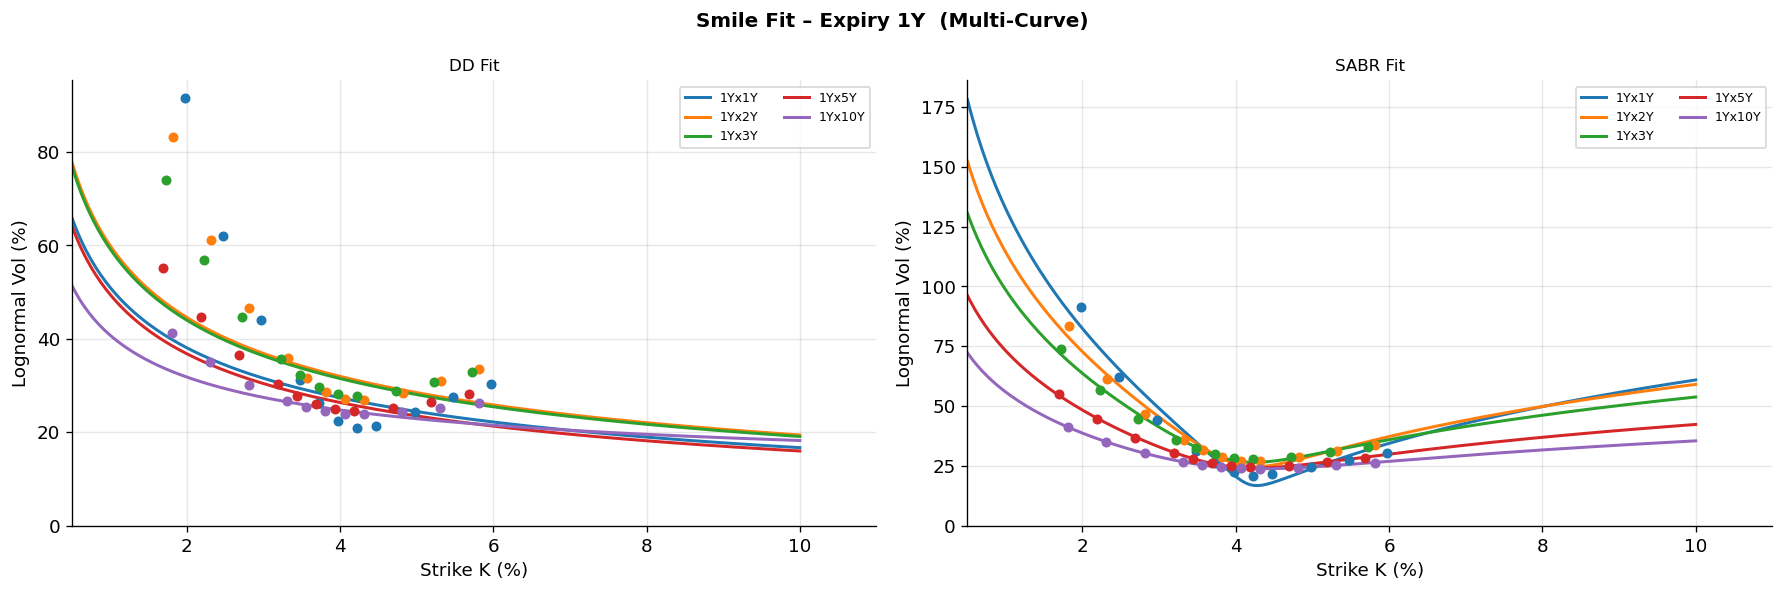

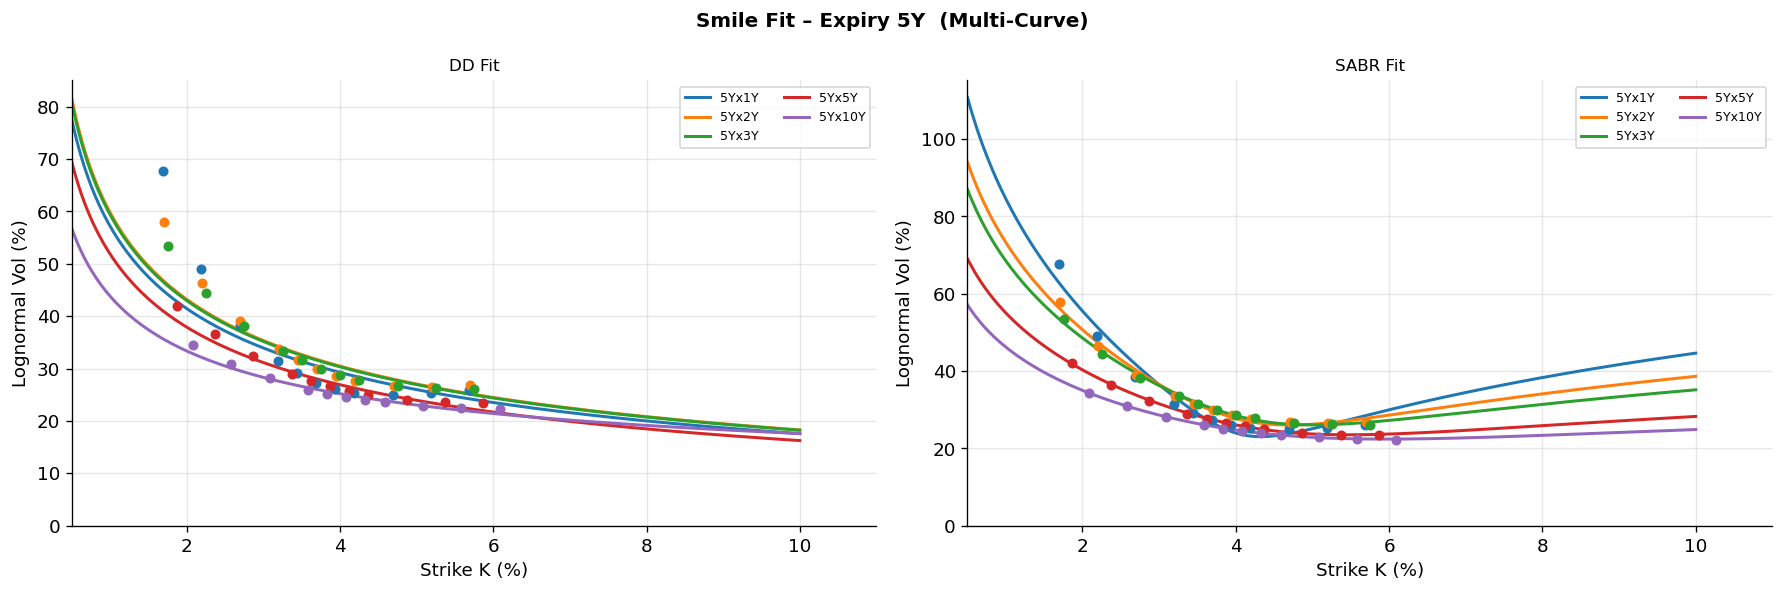

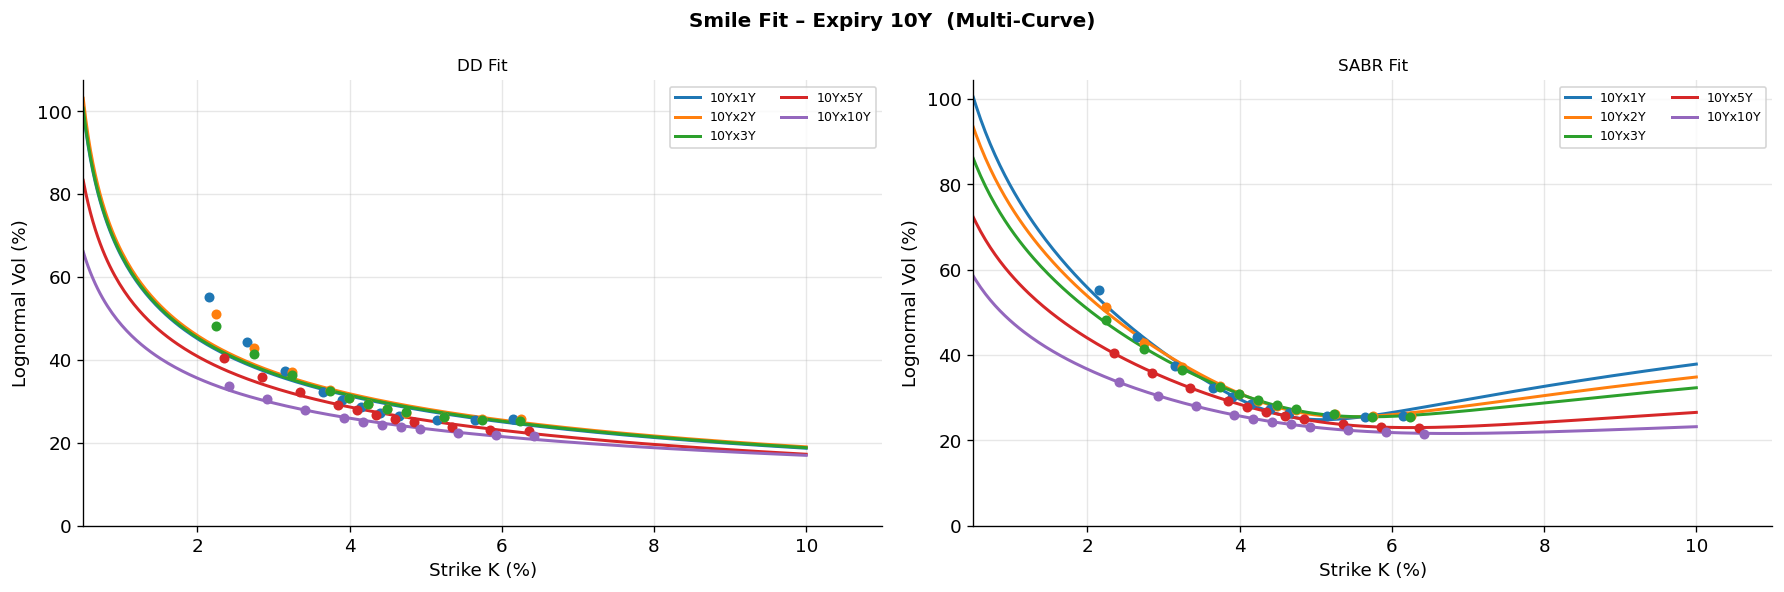

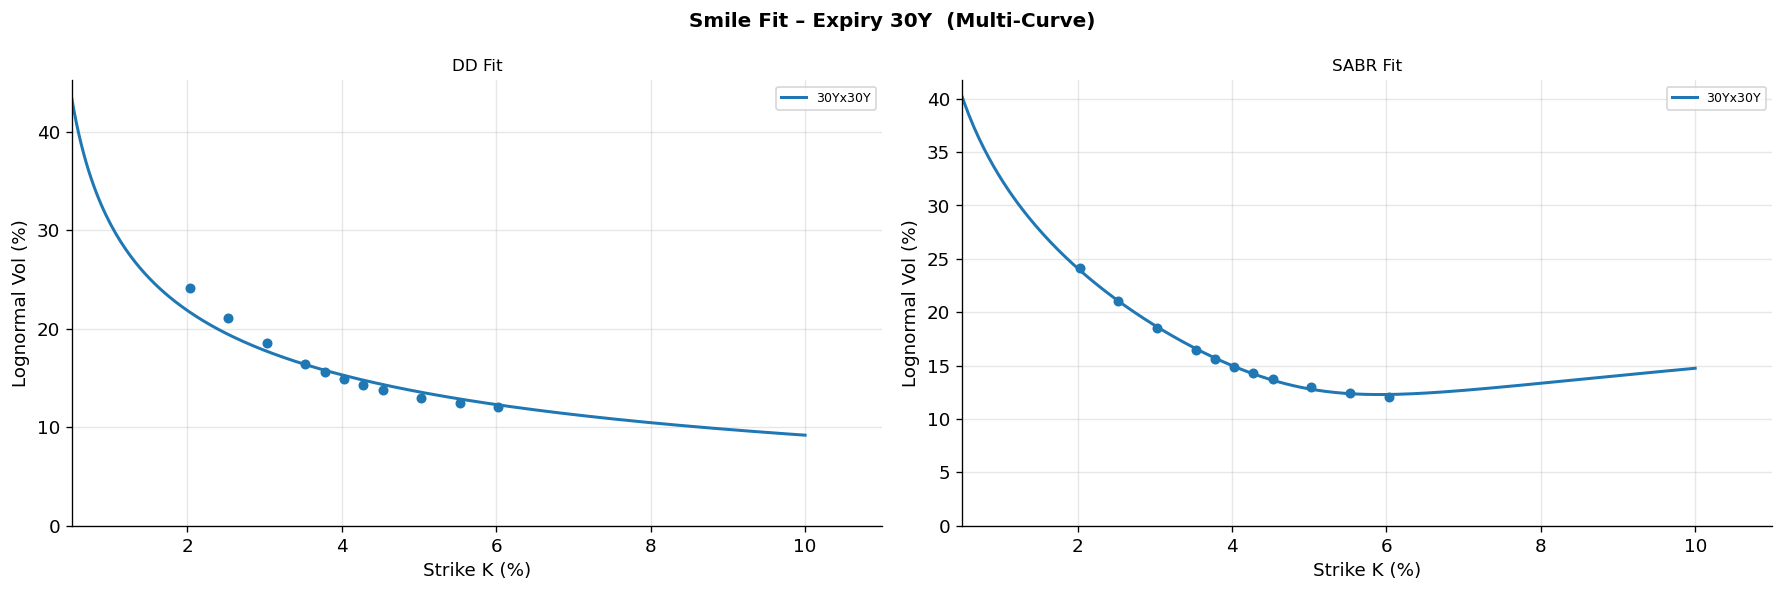

In [65]:
K_grid   = np.linspace(0.005, 0.10, 300)
exp_list = sorted(set(sl["exp_str"] for sl in swaption_slices), key=tenor_to_years)
colors   = plt.cm.tab10.colors

for exp_str in exp_list:
    subset = [sl for sl in swaption_slices if sl["exp_str"] == exp_str]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Smile Fit – Expiry {exp_str}  (Multi-Curve)",
                 fontsize=12, fontweight="bold")

    for ax_dd, ax_sabr in [(axes[0], axes[1])]:
        for idx, sl in enumerate(subset):
            F, A, T = sl["F"], sl["A"], sl["T_exp"]
            c        = colors[idx % 10]
            is_payer = True

            sig, b       = sl.get("dd_params",   (0.20, 0.5))
            a, b_s, rho, nu = sl.get("sabr_params", (0.05, BETA_SABR, -0.3, 0.4))

            dd_v   = [dd_implied_lognormal_vol(F,K,T,sig,b,A,is_payer) for K in K_grid]
            dd_v   = [v*100 if (v is not None and np.isfinite(v)) else np.nan for v in dd_v]
            sabr_v = [sabr_vol(F,K,T,a,b_s,rho,nu)*100 for K in K_grid]

            ax_dd.plot(K_grid*100, dd_v,   color=c, lw=1.8, label=sl["label"])
            ax_sabr.plot(K_grid*100, sabr_v, color=c, lw=1.8, label=sl["label"])

            ks_p = [K for K,v in zip(sl["strikes"],sl["vols_pct"])
                    if v is not None and not (isinstance(v,float) and np.isnan(v))]
            vs_p = [v for v in sl["vols_pct"]
                    if v is not None and not (isinstance(v,float) and np.isnan(v))]
            ax_dd.scatter([k*100 for k in ks_p], vs_p, color=c, marker="o", s=25, zorder=5)
            ax_sabr.scatter([k*100 for k in ks_p], vs_p, color=c, marker="o", s=25, zorder=5)

        for ax, title in [(ax_dd, "DD Fit"), (ax_sabr, "SABR Fit")]:
            ax.set_title(title, fontsize=10)
            ax.set_xlabel("Strike K (%)"); ax.set_ylabel("Lognormal Vol (%)")
            ax.legend(fontsize=7.5, ncol=2)
            ax.set_xlim(0.5, 11); ax.set_ylim(bottom=0)

    fig.tight_layout()
    plt.show()

---
## Summary Statistics

In [66]:
print("=" * 70)
print(" Part II – Calibration Summary")
print("=" * 70)

# Forward swap rates for the three II.3 target swaptions
print("\n[II.3] Target Swaption Details")
print(f"  {'Slice':>12}  {'F (%)':>8}  {'Annuity':>8}  {'ATM Vol':>10}")
print("  " + "-" * 44)
for (exp_s, ten_s) in [("1Y","1Y"),("10Y","10Y"),("30Y","30Y")]:
    sl = next((s for s in swaption_slices
               if s["exp_str"]==exp_s and s["ten_str"]==ten_s), None)
    if sl:
        atm_mkt  = sl["vols_pct"][5]
        atm_str  = f"{atm_mkt:.2f}%" if atm_mkt is not None else "synth"
        print(f"  {sl['label']:>12}  {sl['F']*100:>8.4f}  {sl['A']:>8.4f}  {atm_str:>10}")

# Parameter range summary
print("\n[II.1] DD Parameter Ranges")
sigs = [v for v in sigma_table.values() if np.isfinite(v)]
bets = [v for v in beta_table.values()  if np.isfinite(v)]
print(f"  σ : min={min(sigs):.4f}  max={max(sigs):.4f}  mean={np.mean(sigs):.4f}")
print(f"  β : min={min(bets):.4f}  max={max(bets):.4f}  mean={np.mean(bets):.4f}")

print("\n[II.2] SABR Parameter Ranges")
alps = [v for v in alpha_table.values() if np.isfinite(v)]
rhos = [v for v in rho_table.values()   if np.isfinite(v)]
nus  = [v for v in nu_table.values()    if np.isfinite(v)]
print(f"  α : min={min(alps):.4f}  max={max(alps):.4f}  mean={np.mean(alps):.4f}")
print(f"  ρ : min={min(rhos):.4f}  max={max(rhos):.4f}  mean={np.mean(rhos):.4f}")
print(f"  ν : min={min(nus):.4f}   max={max(nus):.4f}   mean={np.mean(nus):.4f}")

print("\n" + "=" * 70)
print(" ✓ Part II complete")
print("=" * 70)

 Part II – Calibration Summary

[II.3] Target Swaption Details
         Slice     F (%)   Annuity     ATM Vol
  --------------------------------------------
         1Yx1Y    3.9767    0.9353      22.50%
       10Yx10Y    4.4205    5.3356      24.37%
       30Yx30Y    4.0285    5.3968      14.89%

[II.1] DD Parameter Ranges
  σ : min=0.1482  max=0.3259  mean=0.2766
  β : min=0.0001  max=0.2889  mean=0.0388

[II.2] SABR Parameter Ranges
  α : min=0.0684  max=0.1243  mean=0.1078
  ρ : min=-0.6758  max=-0.2015  mean=-0.4810
  ν : min=0.3658   max=2.6117   mean=0.9817

 ✓ Part II complete
